<a href="https://colab.research.google.com/github/litlig/notebooks/blob/main/pixel_art_discrete_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pixel art generation using discrete diffusion

Diffusion models are widely used to generate images. Pixel art, with limited data points and a categorical palette, can be a good fit for discrete diffusion.

The [dataset](https://www.kaggle.com/datasets/litlig/palette-pixel-art) contains 16x16 images in 5 categories. What each category means is not explicily staeted, just infering from the dataset, the first and the last seems to be front facing and side facing of characters, while the other three are less obvious. To simplify, we just use the first one, hopefully to train a model to generate front facing characters by de-masking pixels step by step.

In [1]:
#@title import dataset
import kagglehub
import pandas as pd
import os
import numpy as np

# Download latest version
path = kagglehub.dataset_download("litlig/palette-pixel-art")

print("Path to dataset files:", path)

labels_path = os.path.join(path, "labels.csv")
labels_df = pd.read_csv(labels_path)

labels_df['image_path'] = labels_df['image_path'].apply(lambda x: os.path.join(path, 'palette_images','palette_images', f"image_{int(x.split('_')[-1].split('.')[0])}.png"))

100%|██████████| 107M/107M [00:01<00:00, 104MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/litlig/palette-pixel-art/versions/1


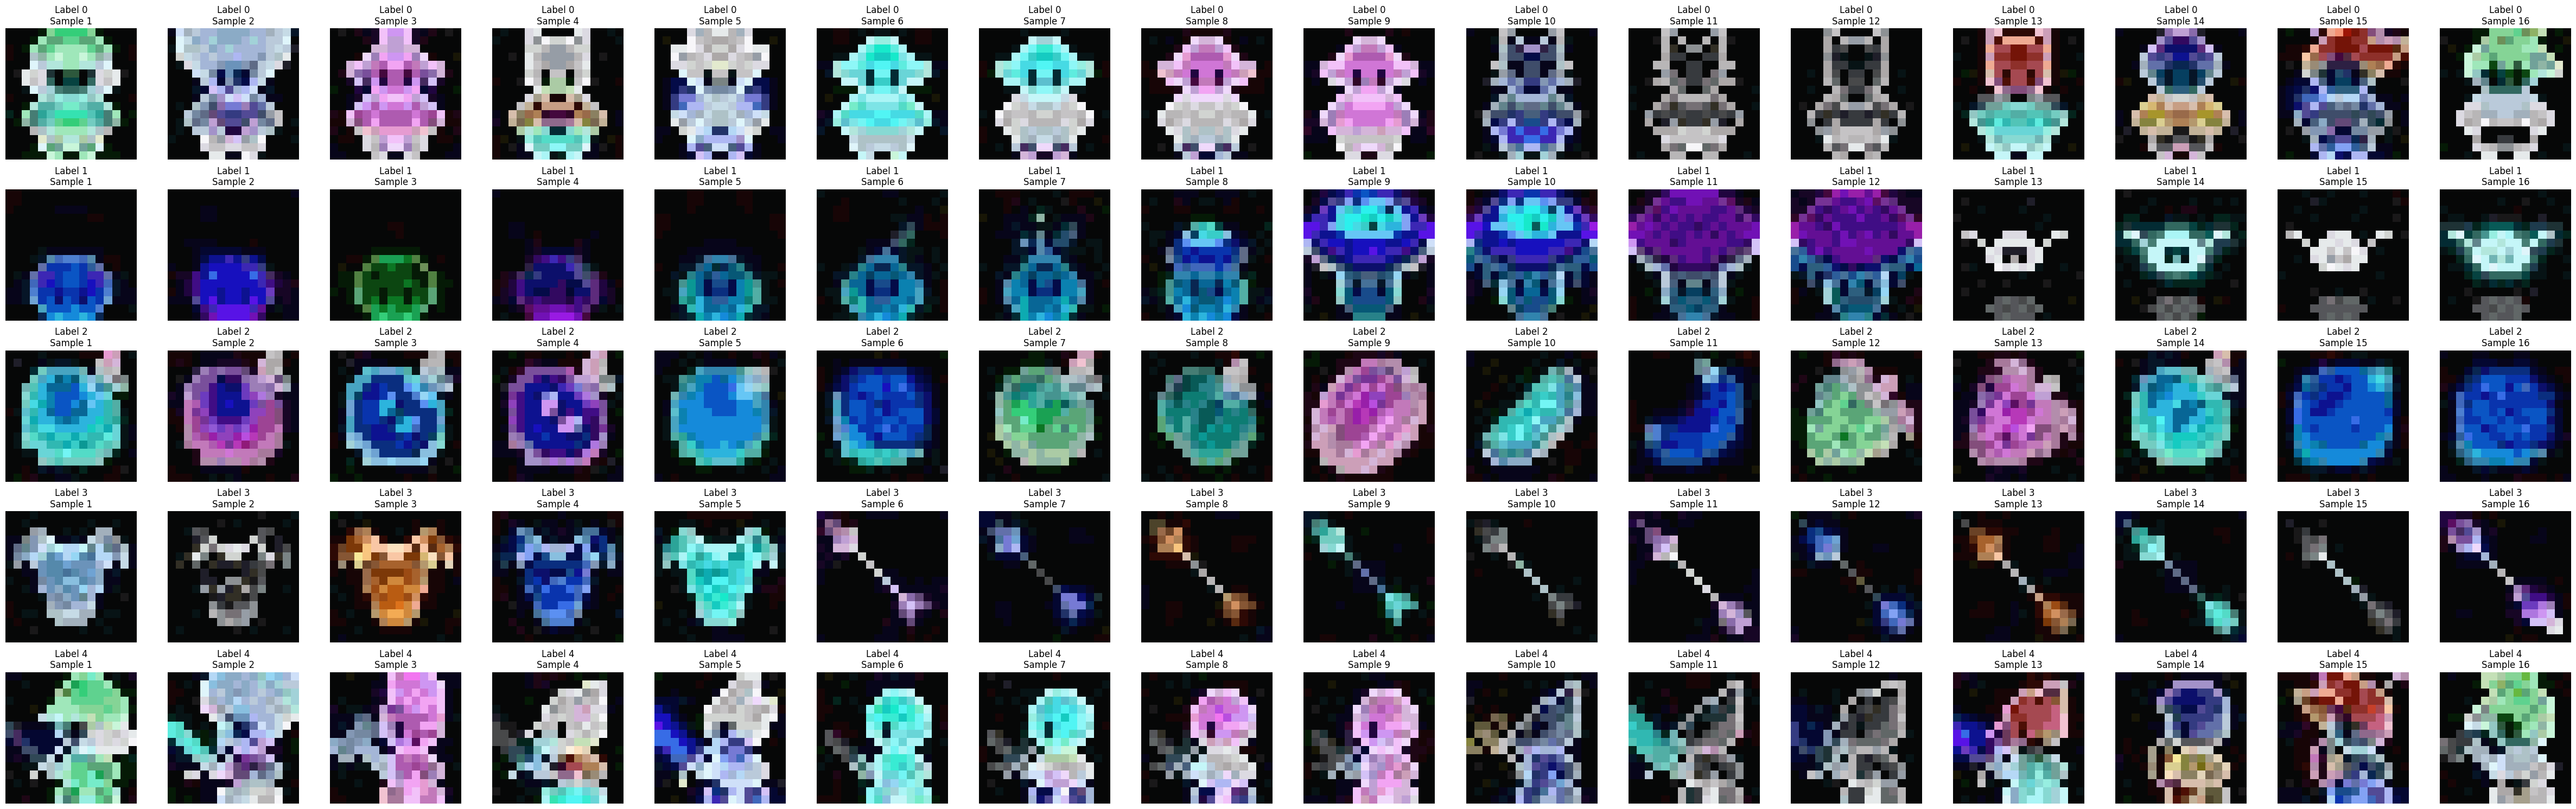

In [2]:
#@title sample image for each label
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Get unique labels
unique_labels = sorted(labels_df['integer_label'].unique())

num_samples_per_label = 16

# Set up the figure for displaying images
fig = plt.figure(figsize=(num_samples_per_label * 3, len(unique_labels) * 3)) # Adjust figure size dynamically

for i, label in enumerate(unique_labels):
    # Filter the DataFrame for the current label and sample 'num_samples_per_label' images
    # Use .sample() to get random samples, or .head() if order doesn't matter
    # Using .head() for consistent output across runs
    sample_image_paths = labels_df[labels_df['integer_label'] == label]['image_path'].head(num_samples_per_label)

    for j, image_path in enumerate(sample_image_paths):
        # Calculate subplot position: (label_index * num_samples_per_label) + sample_index + 1
        plot_index = (i * num_samples_per_label) + j + 1
        plt.subplot(len(unique_labels), num_samples_per_label, plot_index)

        try:
            # Load the image
            img = Image.open(image_path)
            plt.imshow(img)
            plt.title(f'Label {label}\nSample {j+1}')
            plt.axis('off') # Hide axes for cleaner image display
        except FileNotFoundError:
            print(f"Warning: Image not found at {image_path}. Skipping.")
            plt.text(0.5, 0.5, 'Image not found', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
            plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles/images
plt.show()

### Training

The goal to learn a process to convert fully noised/masked image to a front-facing character pixel art. If we know the ending pixel art, we can design a process like this: at each time step, a masked pixel can decide either stay masked to jump to the ending color, a un-masked pixel is always stays in the ending color. the cumulative probability of jump from 0 to t is $\alpha_t$, and it satisfies $\alpha_0 = 0$ and $\alpha_1 = 1$. This $\alpha_t$ is called denoise schedule.

When the ending pixel art is not given, the denoise schedule is still $\alpha_t$, but the ending color to jump to is unknown. The best guess we make here is the most likely ending state given the current partially noised image and time t. We build a multi-head transformer to predict the ending state, the model can be further simplied to skip t as the input as the time information is already embeded in the number of masked pixels.

In [3]:
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader

class PixelArtDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['integer_label']

        # Load image
        image = Image.open(img_path)

        return torch.from_numpy(np.array(image)).long(), torch.tensor(label, dtype=torch.long)

batch_size = 64
data = PixelArtDataset(labels_df[labels_df['integer_label'] == 0])
data_loader = DataLoader(data, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
for images, labels in data_loader:
    print(f"Batch of images shape: {images.shape}") # Expected: [batch_size, 16, 16]
    print(f"Batch of labels shape: {labels.shape}") # Expected: [batch_size]
    break

Batch of images shape: torch.Size([64, 16, 16])
Batch of labels shape: torch.Size([64])


In [4]:
#@title Define a multi-head transformer
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

img_size = 16
p_mask = 256
n_vocab = 257
dim = 32
hidden=64
n_layer = 4
n_head = 4
n_seq = img_size * img_size

class Head(nn.Module):
  def __init__(self, head_size):
    super().__init__()
    assert dim % head_size == 0
    self.head_size = head_size
    self.n_head = dim // head_size
    self.key = nn.Linear(dim, dim, bias=False)
    self.query = nn.Linear(dim, dim, bias=False)
    self.value = nn.Linear(dim, dim, bias=False)

  def forward(self, x): # x, B:n_seq:dim
    B = x.shape[0]
    k = self.key(x).view(B, n_seq, self.n_head, -1).transpose(1,2) # B:n_head:n_seq:head_size
    q = self.query(x).view(B, n_seq, self.n_head, -1).transpose(1,2) # B:n_head:n_seq:head_size
    v = self.value(x).view(B, n_seq, self.n_head, -1).transpose(1,2) # B:n_head:n_seq:head_size
    wei = q @ k.transpose(-2, -1) * self.head_size**-0.5 # B:n_head:n_seq:n_seq
    wei = F.softmax(wei, dim=-1) #B:n_head:n_seq:n_seq
    x = wei @ v # B:n_head:n_seq:head_size
    return x.transpose(1,2).reshape(B, n_seq, -1) # B:n_seq:dim

class MLP(nn.Module):
  def __init__(self, n_hidden) -> None:
    super(MLP, self).__init__()
    self.ln1 = nn.Linear(dim, n_hidden)
    self.ln2 = nn.Linear(n_hidden, dim)

  def forward(self, x):
    x = nn.functional.relu(self.ln1(x))
    x = self.ln2(x)
    return x

class Block(nn.Module):
  def __init__(self, head_size):
    super().__init__()
    self.ln1 = nn.LayerNorm(dim)
    self.ln2 = nn.LayerNorm(dim)
    self.head = Head(head_size)
    self.ffwd = MLP(n_hidden=hidden)

  def forward(self, x):
    x = self.ln1(x + self.head(x))
    x = self.ln2(x + self.ffwd(x))
    return x


# a nn that output logit for each pixel 16:16:(nvocab - 1)
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.emb = nn.Embedding(n_vocab, dim)
    self.pos_emb = nn.Embedding(n_seq, dim)
    self.blocks = nn.Sequential(*[Block(head_size=dim // n_head) for _ in range(n_layer)])
    self.proj = nn.Linear(dim, n_vocab-1)

  def forward(self, x): # x, B:n_seq
    x = self.emb(x) + self.pos_emb(torch.arange(n_seq, device=device)) # B:n_seq:dim
    x = self.blocks(x)
    return self.proj(x) # B:n_seq:n_vocab-1



cuda


In [31]:
model = Net().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
model.train()
losses = []
log_interval = 100
step = 0


In [32]:
for epoch in range(50):
  for images, labels in data_loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    t = torch.rand(batch_size, device=device)
    kappa = torch.bernoulli(t.view(batch_size,1,1).expand(batch_size, img_size, img_size)).long().to(device) # B:16:16
    masked_pos = (kappa == 0)
    xt = p_mask * (1-kappa) + images * kappa
    z = model(xt.view(batch_size,-1))
    loss = F.cross_entropy(z.view(-1, n_vocab-1)[masked_pos.view(-1)], images.view(-1)[masked_pos.view(-1)])
    losses.append(loss.item())
    if step % log_interval == 0:
      print(f"Step: {step}, Loss: {loss.item()}")
    step += 1
    loss.backward()
    optimizer.step()

Step: 0, Loss: 5.7448859214782715
Step: 100, Loss: 4.039109706878662
Step: 200, Loss: 3.586172103881836
Step: 300, Loss: 3.2635183334350586
Step: 400, Loss: 2.9430198669433594
Step: 500, Loss: 2.7948951721191406
Step: 600, Loss: 2.6895604133605957
Step: 700, Loss: 2.5956454277038574
Step: 800, Loss: 2.6083292961120605
Step: 900, Loss: 2.519861936569214
Step: 1000, Loss: 2.4441821575164795
Step: 1100, Loss: 2.378507614135742
Step: 1200, Loss: 2.270247220993042
Step: 1300, Loss: 2.130094528198242
Step: 1400, Loss: 2.065760612487793
Step: 1500, Loss: 2.0722830295562744
Step: 1600, Loss: 1.9691123962402344
Step: 1700, Loss: 1.952682614326477
Step: 1800, Loss: 2.0749027729034424
Step: 1900, Loss: 1.844700574874878
Step: 2000, Loss: 1.8669652938842773
Step: 2100, Loss: 1.777402639389038
Step: 2200, Loss: 1.652037262916565
Step: 2300, Loss: 1.7805694341659546
Step: 2400, Loss: 1.8963772058486938
Step: 2500, Loss: 1.6511898040771484
Step: 2600, Loss: 1.6729941368103027
Step: 2700, Loss: 1.5580

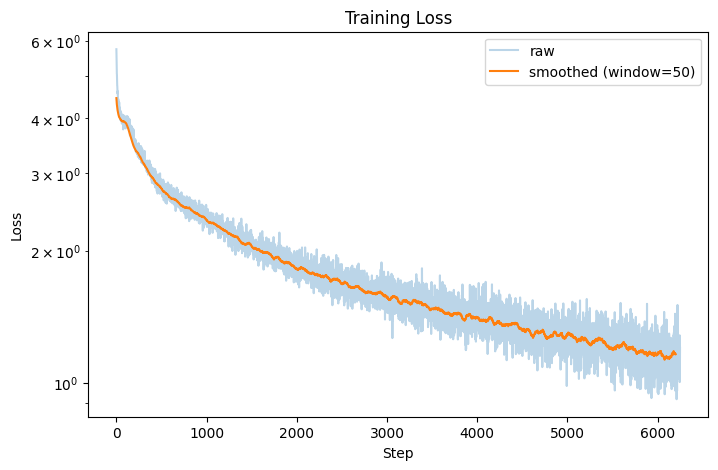

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(x, window=50):
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 5))
plt.plot(losses, alpha=0.3, label='raw')
plt.plot(moving_average(losses, window=50), label='smoothed (window=50)')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.title('Training Loss')
plt.show()

In [34]:
#@title sampling
snapshot_every = 10  # save every 10 steps
snapshots = {}

model.eval()
steps = 1000
n_sample = 64
x = p_mask * torch.ones((n_sample, img_size,img_size), device=device).long()
alpha_prev = 0
for step in range(steps):
  alpha_curr = step/steps
  alpha_t = ((alpha_curr - alpha_prev)/(1-alpha_prev)) * torch.ones(n_sample, device=device)
  kappa = torch.bernoulli(alpha_t.view(n_sample,1,1).expand(n_sample, img_size, img_size)).long().to(device)
  kappa = kappa * (x == p_mask).long()
  logits = model(x.view(n_sample, -1))
  sample = torch.multinomial(F.softmax(logits, dim = -1).view(n_sample * img_size * img_size, -1), num_samples=1).view(n_sample, img_size, img_size)
  x = sample.view(n_sample, img_size, img_size) * kappa + x * (1-kappa)
  alpha_prev = alpha_curr
  if step % snapshot_every == 0 or step == steps - 1:
    snapshots[step] = x.detach().cpu().clone()

In [45]:
#@title plot the unmasking process
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open(labels_df[labels_df['integer_label'] == 0].loc[0]['image_path'])
palette = np.array(img.getpalette()).reshape(-1, 3).astype(np.uint8)

def indices_to_rgb(idx_tensor, palette, p_mask, mask_color=(128, 128, 128)):
    """idx_tensor: (H, W) or (N, H, W) long tensor of palette indices (may include p_mask)"""
    idx = idx_tensor.numpy()
    is_masked = (idx == p_mask)
    idx_safe = np.where(is_masked, 0, idx)  # dummy index to avoid out-of-bounds lookup
    rgb = palette[idx_safe]                  # (..., 3)
    rgb[is_masked] = mask_color               # gray out still-masked pixels
    return rgb.astype(np.uint8)

def make_grid_frame(x_step, palette, p_mask, upscale=4, pad=2, mask_color=(128,128,128)):
    """x_step: (16, H, W) tensor of palette indices for one timestep"""
    n = x_step.shape[0]
    grid_size = int(n ** 0.5)
    h, w = x_step.shape[1], x_step.shape[2]

    cell_h, cell_w = h * upscale, w * upscale
    canvas = np.full(
        (grid_size * (cell_h + pad) - pad, grid_size * (cell_w + pad) - pad, 3),
        255, dtype=np.uint8
    )

    for i in range(n):
        row, col = divmod(i, grid_size)
        rgb = indices_to_rgb(x_step[i], palette, p_mask, mask_color)  # (h, w, 3)
        img_up = np.array(
            Image.fromarray(rgb).resize((cell_w, cell_h), Image.NEAREST)
        )
        y0 = row * (cell_h + pad)
        x0 = col * (cell_w + pad)
        canvas[y0:y0+cell_h, x0:x0+cell_w] = img_up

    return Image.fromarray(canvas)

step_keys = sorted(snapshots.keys())
frames = [make_grid_frame(snapshots[s], palette, p_mask) for s in step_keys]

durations = [100] * (len(frames) - 1) + [1500]  # last frame shown for 1.5s

frames[0].save(
    'unmasking_process.gif',
    save_all=True,
    append_images=frames[1:],
    duration=durations,
    loop=0
)



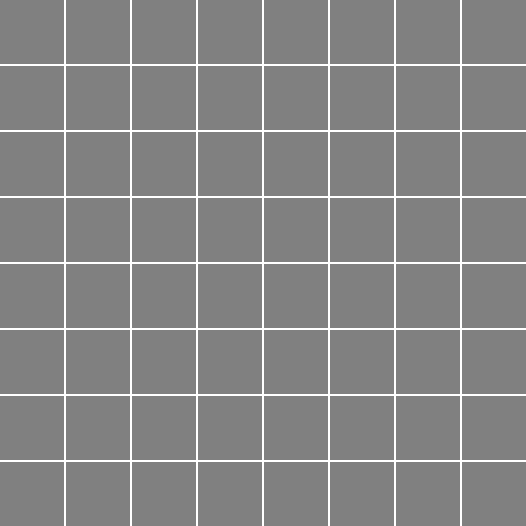

In [46]:
from IPython.display import Image as IPImage
IPImage('unmasking_process.gif')